# Multilingual Characterization and Extraction of Narratives from Online News
## Subtask 2: Narrative Classification with Llama-3.2-3B (LoRA / Unsloth)
---
**Author:** Manuel Carlucci  
**Student ID:** 855237  
**Email:** m.carlucci69@studenti.uniba.it

### Task Definition
Given a news article and a two-level taxonomy of narrative labels, assign all appropriate **sub-narrative labels**.
Dominant narratives are **derived automatically** from sub-narrative predictions via the hierarchy mapping.

**Model:** `unsloth/Llama-3.2-3B-Instruct-bnb-4bit`  
**Method:** Parameter-Efficient Fine-Tuning with **LoRA** (Low-Rank Adaptation) via Unsloth  
**Prompt strategy:** Chat-template instruction following — article as user message, labels as assistant response  
**Evaluation:** Micro-F1 @ fine (sub-narrative) + Micro-F1 @ coarse (dominant narrative)

### Key design choices
- `MAX_SEQ_LENGTH=2048` — Llama supports long context; news articles fit comfortably
- `r=16, lora_alpha=16` — LoRA rank/alpha, standard for efficient fine-tuning
- `warmup_steps=10` — gentle LR ramp-up on small dataset (~399 samples)
- **Single 80/20 holdout split** instead of 5-fold CV: with a 3B model, each training run takes 20-40 min on a T4 GPU — 5 folds would cost 2-3 hours before even training the final model. A single validation split is sufficient to verify the model is learning and to compare against DistilBERT.
- No threshold tuning needed — the LLM directly outputs label strings, parsed back to binary vectors

## Setup and Installation

In [ ]:
%%capture
# Install Unsloth (optimized LLM fine-tuning library) and its dependencies.
# The Colab branch installs the correct xformers version for the detected PyTorch version.
# We also pin transformers and trl to versions compatible with Unsloth.
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2
!pip install scikit-learn

In [ ]:
# Standard library and third-party imports.
# FastLanguageModel is Unsloth's optimized wrapper around HuggingFace models.
# SFTTrainer (Supervised Fine-Tuning Trainer) from TRL handles chat-template training.
# MultiLabelBinarizer converts label lists to binary vectors for evaluation.
import os, json, pickle, re, math
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

from unsloth import FastLanguageModel
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

# Fix all random seeds for reproducibility across numpy, torch, and Python random
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Using device: cuda


## Mount Google Drive & Configure Paths

In [ ]:
# Mount Google Drive to access training data, label files, and save model artifacts.
# All paths are relative to the NLP_Project folder in MyDrive.
from google.colab import drive
drive.mount("/content/drive")

BASE              = "/content/drive/MyDrive/NLP_Project"
NARRATIVES        = f"{BASE}/subtask_2/subtask2_narratives.txt"
SUBNARRATIVES     = f"{BASE}/subtask_2/subtask2_subnarratives.txt"
TRAIN_DOCS_DIR    = f"{BASE}/training/EN/raw-documents"
TRAIN_ANNOTATIONS = f"{BASE}/subtask_2/training/EN/subtask-2-annotations.txt"
TEST_DOCS_DIR     = f"{BASE}/subtask_2/test/EN/subtask-2-documents"
GOLD_FILE         = f"{BASE}/subtask_2/test/EN/subtask-2-annotations.txt"
OUTPUT_FILE       = f"{BASE}/predictions_subtask2_EN_llm.txt"
SAVE_DIR          = f"{BASE}/llm_subtask2_final"
LANG              = "EN"

Mounted at /content/drive


## Load Label Taxonomy

Labels are loaded from the plain-text files on Drive (one label per line).
- `narrative_labels`: the 22 coarse dominant narrative categories
- `subnarrative_labels`: the 91 fine-grained sub-narrative classes used for classification

In [ ]:
def load_label_list(path):
    """Read a plain-text label file (one label per line)."""
    with open(path, "r", encoding="utf-8") as f:
        return [line.strip() for line in f if line.strip()]

narrative_labels    = load_label_list(NARRATIVES)
subnarrative_labels = load_label_list(SUBNARRATIVES)

print(f"Dominant narrative labels : {len(narrative_labels)}")
print(f"Sub-narrative labels      : {len(subnarrative_labels)}")

Dominant narrative labels : 22
Sub-narrative labels      : 91


## Load and Parse Data

Same `parse_annotations` and `load_texts` helpers from the Gensim pipeline.
- `parse_annotations`: reads the TSV annotation file, splits semicolon-separated label strings, deduplicates
- `load_texts`: reads each article's raw text from the documents directory by article ID

In [ ]:
def parse_annotations(annotation_file):
    """
    Parse the TSV annotation file into a DataFrame.
    Each row contains: article_id, language, dom_narratives (list), subnarratives (list).
    dict.fromkeys() is used to remove duplicate labels while preserving order.
    """
    records = []
    with open(annotation_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split("\t")
            article_id = parts[0].strip()
            lang = article_id.split("_")[0] if "_" in article_id else "UNK"
            dom_str = parts[1].strip() if len(parts) > 1 else "Other"
            sub_str = parts[2].strip() if len(parts) > 2 else dom_str
            dom_labels = list(dict.fromkeys(l.strip() for l in dom_str.split(";") if l.strip()))
            sub_labels = list(dict.fromkeys(l.strip() for l in sub_str.split(";") if l.strip()))
            records.append({
                "article_id"    : article_id,
                "language"      : lang,
                "dom_narratives": dom_labels,
                "subnarratives" : sub_labels,
            })
    return pd.DataFrame(records)

def load_texts(docs_dir, article_ids):
    """Load raw article text for each article_id from the documents directory."""
    texts = {}
    for aid in article_ids:
        fpath = os.path.join(docs_dir, aid)
        if os.path.exists(fpath):
            with open(fpath, "r", encoding="utf-8", errors="ignore") as f:
                texts[aid] = f.read()
        else:
            texts[aid] = ""
    return texts

# Load and filter to English articles only
df_raw = parse_annotations(TRAIN_ANNOTATIONS)
df_raw = df_raw[df_raw["language"] == LANG].reset_index(drop=True)
texts_raw = load_texts(TRAIN_DOCS_DIR, df_raw["article_id"].tolist())
df_raw["text"] = df_raw["article_id"].map(texts_raw)

print(f"Training samples : {len(df_raw)}")
print(df_raw.head(3))

Training samples : 399
         article_id language                       dom_narratives  \
0  EN_CC_100013.txt       EN  [CC: Criticism of climate movement]   
1  EN_UA_300009.txt       EN                              [Other]   
2  EN_UA_300017.txt       EN                              [Other]   

                                       subnarratives  \
0  [CC: Criticism of climate movement: Ad hominem...   
1                                            [Other]   
2                                            [Other]   

                                                text  
0  Bill Gates Says He Is ‘The Solution’ To Climat...  
1  Russia: Clashes erupt in Bashkortostan as righ...  
2  McDonald's to exit Russia, sell business in co...  


## Multi-label Binarization and Hierarchical Label Mapping

Sub-narrative labels are converted to binary vectors using `MultiLabelBinarizer` — each position
in the vector corresponds to one sub-narrative class (1 = present, 0 = absent).

The `sub2dom` mapping is built from the training annotations: for each sub-narrative,
we record which dominant narrative it belongs to, enabling coarse-level evaluation.

In [ ]:
def without_other(label_list):
    # Exclude the catch-all 'Other' label from binarization —
    # it is not a real semantic class and is handled separately at output time.
    return [l for l in label_list if l != "Other"]

# Fine-grained (sub-narrative) binarization
# MultiLabelBinarizer converts a list of active labels into a fixed-size binary vector.

# all_sub_labels = sorted(set( l for labels in df_raw["subnarratives"].apply(without_other) for l in labels ))
# We want to treat other a a number like the others when predicted
all_sub_labels = sorted(set(
    l for labels in df_raw["subnarratives"] for l in labels
))
sub_mlb = MultiLabelBinarizer(classes=all_sub_labels)
sub_mlb.fit([all_sub_labels])
Y_sub = sub_mlb.transform(df_raw["subnarratives"])

# Coarse-grained (dominant narrative) binarization — used only for evaluation
all_dom_labels = sorted(set(
    l for labels in df_raw["dom_narratives"] for l in labels
) | {"Other"})  # forza "Other" anche se non appare nei dati - utile per fallback (se nei dati di training non c'è Other, lo aggiung automaticamente)

dom_mlb = MultiLabelBinarizer(classes=all_dom_labels)
dom_mlb.fit([all_dom_labels])
Y_dom = dom_mlb.transform(df_raw["dom_narratives"])

# Build sub -> dominant hierarchy mapping from training annotations.
# For each sub-narrative, record the dominant narrative it belongs to
# by matching the prefix (e.g. "CC: ..." -> "CC: Climate change is beneficial").
sub2dom = {}
for _, row in df_raw.iterrows():
    for sub in row["subnarratives"]:
        if sub == "Other":
            continue
        for dom in row["dom_narratives"]:
            if dom == "Other":
                continue
            if sub.startswith(dom.split(":")[0]):
                sub2dom[sub] = dom

NUM_LABELS = len(all_sub_labels)
print(f"Sub-narrative classes  : {NUM_LABELS}")
print(f"Dominant narrative cls : {len(all_dom_labels)}")
print(f"Hierarchy entries      : {len(sub2dom)}")

Sub-narrative classes  : 84
Dominant narrative cls : 22
Hierarchy entries      : 83


## Train / Validation Split

Instead of 5-fold cross-validation (too expensive for a 3B model on Colab), we use a single
**80/20 stratified-like split** with a fixed random seed.
This gives us ~320 training samples and ~80 validation samples — the same size as one fold of the DistilBERT CV,
allowing a fair qualitative comparison of validation performance.

In [ ]:
# Split indices — stratification is not straightforward in multi-label settings,
# so we use a plain random split with fixed seed for reproducibility.
all_indices = np.arange(len(df_raw))
train_idx, val_idx = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=RANDOM_SEED,
    shuffle=True,
)

texts_arr = np.array(df_raw["text"].fillna("").tolist())

X_tr_texts  = texts_arr[train_idx].tolist()
X_val_texts = texts_arr[val_idx].tolist()
Ys_tr  = Y_sub[train_idx]
Ys_val = Y_sub[val_idx]
Yd_val = Y_dom[val_idx]

print(f"Training samples   : {len(X_tr_texts)}")
print(f"Validation samples : {len(X_val_texts)}")
print(f"Labels with zero positives (train) : {(Ys_tr.sum(axis=0) == 0).sum()}")
print(f"Mean positive rate (train)         : {Ys_tr.mean():.4f}")
print(f"Samples with >= 1 label (train)    : {(Ys_tr.sum(axis=1) > 0).mean()*100:.2f}%")

Training samples   : 319
Validation samples : 80
Labels with zero positives (train) : 2
Mean positive rate (train)         : 0.0264
Samples with >= 1 label (train)    : 100.00%


## LoRA Model Setup (Unsloth + Llama-3.2-3B)

**LoRA (Low-Rank Adaptation)** fine-tunes only small trainable matrices added to frozen model layers.
Instead of updating all 3B parameters, LoRA approximates the weight update as **ΔW ≈ A × B**,
where A and B are low-rank matrices (rank `r=16`), reducing trainable parameters by ~99%.

- `target_modules`: the attention and MLP projection layers where LoRA is injected
- `lora_alpha=16`: scaling factor for the LoRA update (equal to r → no extra scaling)
- `use_gradient_checkpointing="unsloth"`: Unsloth's memory-efficient checkpointing — fits 2x larger batch
- `use_rslora=True`: Rank-Stabilized LoRA — more stable gradients at higher ranks
- `load_in_4bit=True`: 4-bit NF4 quantization of base weights — reduces VRAM from ~6GB to ~2.5GB

In [ ]:
MODEL_NAME     = "unsloth/Llama-3.2-3B-Instruct-bnb-4bit"
MAX_SEQ_LENGTH = 4096    # Llama supports up to 128k with RoPE scaling; 2048 is sufficient for news articles but got truncated in training, so we increase
DTYPE          = None   # auto-detect: float16 for T4/V100, bfloat16 for Ampere+
LOAD_IN_4BIT   = True   # 4-bit quantization — reduces VRAM footprint significantly

# Load the base model and tokenizer from Unsloth's pre-quantized HuggingFace hub repository.
# Unsloth applies custom CUDA kernels for faster attention and forward passes.
base_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name      = MODEL_NAME,
    max_seq_length  = MAX_SEQ_LENGTH,
    dtype           = DTYPE,
    load_in_4bit    = LOAD_IN_4BIT,
)

print(f"Model loaded: {MODEL_NAME}")
print(f"Vocab size  : {tokenizer.vocab_size}")

==((====))==  Unsloth 2026.6.1: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Model loaded: unsloth/Llama-3.2-3B-Instruct-bnb-4bit
Vocab size  : 128000


In [ ]:
def get_lora_model():
    """
    Attach LoRA adapters to the frozen base model.
    This creates a new PEFT model with trainable low-rank matrices injected
    into the attention (q, k, v, o) and MLP (gate, up, down) projection layers.
    The base model weights remain frozen — only adapter weights are updated.
    """
    model = FastLanguageModel.get_peft_model(
        base_model,
        r                          = 16,    # LoRA rank: higher = more capacity, more VRAM
        target_modules             = ["q_proj", "k_proj", "v_proj", "o_proj",
                                      "gate_proj", "up_proj", "down_proj"],
        lora_alpha                 = 16,    # scaling = lora_alpha / r = 1.0
        lora_dropout               = 0.1,     # 0 is optimized by Unsloth, add regularization
        bias                       = "none",
        use_gradient_checkpointing = "unsloth",
        random_state               = RANDOM_SEED,
        use_rslora                 = True,  # rank-stabilized LoRA for more stable training
        loftq_config               = None,
    )
    return model

## Prompt Formatting

The model is trained with a **chat-template instruction** format (Llama-3 style):

```
<|system|> You are a narrative classification assistant. [full taxonomy] </s>
<|user|> Article: [article text] </s>
<|assistant|> Label A; Label B; Label C </s>
```

- The **system prompt** contains the full label taxonomy so the model knows exactly which labels are valid
- The **user turn** provides the article (truncated to 3000 chars to avoid OOM)
- The **assistant turn** contains the expected output: semicolon-separated sub-narrative labels

At inference, we strip the prompt and parse the generated assistant text back to a binary vector.

OLD VERSION - predict of label, not number referred to label. We have the labels in a file



```
SYSTEM_PROMPT = (
    "You are a narrative classification assistant. "
    "Given a news article, output ONLY the applicable sub-narrative labels from the taxonomy below, "
    "separated by semicolons. If no label applies, output 'Other'. "
    "Do not explain or add any other text.\n\n"
    "Available sub-narrative labels:\n" + "\n".join(f"- {l}" for l in all_sub_labels)
)

def labels_to_string(label_indices, classes):
    """Convert a binary label vector to a semicolon-separated label string for the assistant turn."""
    labels = [classes[i] for i in range(len(classes)) if label_indices[i] == 1]
    return "; ".join(labels) if labels else "Other"

```



In [ ]:
# Build the system prompt once — it includes the full sub-narrative taxonomy
# so the model can reference valid label names during generation.
SYSTEM_PROMPT = (
    "You are a narrative classification assistant. "
    "Given a news article, identify ALL applicable sub-narrative labels "
    "from the numbered list below and output ONLY their numbers separated by semicolons. "
    "Consider every label carefully, including rare and specific ones. "
    "An article can have multiple labels. "
    "Example output: 3; 17; 42\n"
    "If no label applies at all, output: 0\n\n"
    "Sub-narrative labels:\n"
    + "\n".join(f"{i+1}. {l}" for i, l in enumerate(all_sub_labels))
)

def labels_to_string(label_indices, classes):
    """
    Convert binary label vector to semicolon-separated 1-based indices.
    Must match the numbered taxonomy in SYSTEM_PROMPT so the model learns
    to output numbers during training and replicates that at inference.
    """
    indices = [str(i + 1) for i in range(len(classes)) if label_indices[i] == 1]
    return "; ".join(indices) if indices else "0"


def format_sample(text, y_row):
    """
    Build a full chat-template string for one training sample.
    tokenizer.apply_chat_template() inserts the correct special tokens
    (e.g. <|begin_of_text|>, <|start_header_id|>) for the Llama-3 format.
    add_generation_prompt=False: include the assistant turn (we have the gold labels).
    """
    messages = [
        {"role": "system",    "content": SYSTEM_PROMPT},
        {"role": "user",      "content": f"Article:\n{text[:3000]}"},
        {"role": "assistant", "content": labels_to_string(y_row, all_sub_labels)},
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)

def build_sft_dataset(texts_list, y_matrix):
    """
    Build a HuggingFace Dataset of formatted chat strings for SFTTrainer.
    SFTTrainer expects a dataset with a 'text' column containing the full formatted prompt.
    """
    from datasets import Dataset
    formatted = [format_sample(t, y) for t, y in zip(texts_list, y_matrix)]
    return Dataset.from_dict({"text": formatted})

# Sanity check: print the first 800 chars of a formatted training sample
print(format_sample(df_raw["text"].iloc[0][:500], Y_sub[0])[:800])

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 05 Jun 2026

You are a narrative classification assistant. Given a news article, identify ALL applicable sub-narrative labels from the numbered list below and output ONLY their numbers separated by semicolons. Consider every label carefully, including rare and specific ones. An article can have multiple labels. Example output: 3; 17; 42
If no label applies at all, output: 0

Sub-narrative labels:
1. CC: Amplifying Climate Fears: Amplifying existing fears of global warming
2. CC: Amplifying Climate Fears: Doomsday scenarios for humans
3. CC: Amplifying Climate Fears: Other
4. CC: Climate change is beneficial: CO2 is beneficial
5. CC: Climate change is beneficial: Temperature increa


## Evaluation Helpers & Label Parsing

Unlike DistilBERT (which outputs sigmoid probabilities requiring threshold tuning),
the LLM directly generates a text string of labels.

`parse_output_to_binary` converts this string back to a binary vector by checking
each semicolon-separated token against the known taxonomy — unknown tokens are silently ignored.

OLD VERSION


```
def parse_output_to_binary(output_text, classes):
    """
    Parse LLM-generated label string -> binary numpy array.
    Splits on semicolons, strips whitespace, checks membership in the known taxonomy.
    Labels not in the taxonomy (hallucinations or formatting errors) are ignored.
    """
    class_set = set(classes)
    predicted = set()
    for part in output_text.split(";"):
        part = part.strip()
        if part in class_set:
            predicted.add(part)
    return np.array([1 if c in predicted else 0 for c in classes], dtype=int)

  def parse_output_to_binary(output_text, classes):
    class_set = set(classes)
    predicted = set()
    # split on both newlines and semicolons
    for part in re.split(r'[;\n]', output_text):
        part = part.strip()
        if part in class_set:
            predicted.add(part)
    return np.array([1 if c in predicted else 0 for c in classes], dtype=int)


        
def fine_pred_to_coarse(y_pred_fine):
    """
    Map a sub-narrative binary prediction matrix to a dominant narrative binary matrix.
    Uses the sub2dom hierarchy mapping built from training annotations.
    This gives us the coarse-level predictions for F1@coarse evaluation.
    """
    y_coarse = np.zeros((y_pred_fine.shape[0], len(all_dom_labels)), dtype=int)
    dom_list  = list(dom_mlb.classes_)
    for i in range(y_pred_fine.shape[0]):
        for j, sub in enumerate(all_sub_labels):
            if y_pred_fine[i, j] == 1 and sub in sub2dom:
                dom = sub2dom[sub]
                if dom in dom_list:
                    y_coarse[i, dom_list.index(dom)] = 1
    return y_coarse
```



FIX fine_pred_to_coarse:

Scenario: il modello predice "URW: Speculating war outcomes: Russian army is collapsing", ma questo sub-narrative non è mai apparso nel training → non è in sub2dom → il loop non assegna nessun dominant → y_coarse[i] rimane tutto zero → l'articolo ha predizioni sub ma zero predizioni coarse → F1@coarse penalizzato ingiustamente.
Il fix: dopo il loop, se y_coarse[i].sum() == 0 nonostante ci fossero real_subs, assegna "Other" come fallback coarse.

In [ ]:


def parse_output_to_binary(output_text, classes):
    """
    Parse LLM output of semicolon-separated indices -> binary vector.
    - Numeric indices map directly to the official taxonomy (1-indexed).
    - '0' or no valid index -> fallback to 'Other' if present in classes.
    - 'Other' is included in classes, so it can be predicted both
      explicitly (by its number) and as automatic fallback.
    """
    n         = len(classes)
    vec       = np.zeros(n, dtype=int)
    any_valid = False

    for part in output_text.split(";"):
        part = part.strip()
        try:
            idx = int(part) - 1        # 1-indexed → 0-indexed
            if 0 <= idx < n:
                vec[idx] = 1
                any_valid = True
        except ValueError:
            pass                        # ignore non-numeric tokens

    # Fallback: if no valid index was produced, assign 'Other'
    if not any_valid and "Other" in classes:
        other_idx = list(classes).index("Other")
        vec[other_idx] = 1

    return vec

def fine_pred_to_coarse(y_pred_fine):
    y_coarse = np.zeros((y_pred_fine.shape[0], len(all_dom_labels)), dtype=int)
    dom_list = list(dom_mlb.classes_)

    for i in range(y_pred_fine.shape[0]):
        # Collect all predicted sub-narratives for this sample
        predicted_subs = [
            all_sub_labels[j]
            for j in range(len(all_sub_labels))
            if y_pred_fine[i, j] == 1
        ]

        # Filter out 'Other' to see if there are real sub-narrative predictions
        real_subs = [s for s in predicted_subs if s != "Other"]

        if real_subs:
            for sub in real_subs:
                if sub in sub2dom:
                    dom = sub2dom[sub]
                    if dom in dom_list:
                        y_coarse[i, dom_list.index(dom)] = 1
            # Fallback: se nessun mapping trovato aggiungi OTHER
            if y_coarse[i].sum() == 0 and "Other" in dom_list:
                y_coarse[i, dom_list.index("Other")] = 1
        else:
            if "Other" in dom_list:
                y_coarse[i, dom_list.index("Other")] = 1

    return y_coarse


def evaluate(y_true_sub, y_pred_sub, y_true_dom, y_pred_dom, label=""):
    """Compute and print Micro-F1 at both fine (sub-narrative) and coarse (dominant) level."""
    f1_fine   = f1_score(y_true_sub, y_pred_sub, average="micro", zero_division=0)
    f1_coarse = f1_score(y_true_dom, y_pred_dom, average="micro", zero_division=0)
    print(f"[{label}]  F1@fine={f1_fine:.4f}   F1@coarse={f1_coarse:.4f}")
    return f1_fine, f1_coarse



from tqdm import tqdm   # to have log of how the inference is going (percentage of completeness, otherwise we stare at the void hoping it is working)

def run_inference(model, tokenizer, texts_list):
    """
    Run greedy inference on a list of article texts.
    For each text:
      1. Build the user+system prompt (no assistant turn — generation prompt enabled)
      2. Tokenize and move to GPU
      3. Generate up to 256 new tokens (sufficient for a label list)
      4. Decode only the generated portion (strip the input prompt)
      5. Parse the decoded string to a binary label vector

    temperature=0.1 and do_sample=False give near-deterministic greedy decoding.
    """
    FastLanguageModel.for_inference(model)
    preds = []
    for text in tqdm(texts_list, desc="Inference"):
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": f"Article:\n{text[:3000]}"},
        ]
        input_ids = tokenizer.apply_chat_template(
            messages,
            tokenize=True,
            add_generation_prompt=True,
            return_tensors="pt",
        ).to(DEVICE)

        with torch.no_grad():
            output_ids = model.generate(
                input_ids,
                max_new_tokens=256,
                temperature=0.1,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )

        generated = tokenizer.decode(
            output_ids[0][input_ids.shape[1]:],
            skip_special_tokens=True,
        ).strip()

        preds.append(parse_output_to_binary(generated, all_sub_labels))

    return np.array(preds)

OLD VERSION



```
# OLD VERSION



def run_inference(model, tokenizer, texts_list):
    """
    Run greedy inference on a list of article texts.
    For each text:
      1. Build the user+system prompt (no assistant turn — generation prompt enabled)
      2. Tokenize and move to GPU
      3. Generate up to 256 new tokens (sufficient for a label list)
      4. Decode only the generated portion (strip the input prompt)
      5. Parse the decoded string to a binary label vector

    temperature=0.1 and do_sample=False give near-deterministic greedy decoding.
    """
    FastLanguageModel.for_inference(model)  # enable Unsloth's 2x faster inference kernel
    preds = []
    for text in texts_list:
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": f"Article:\n{text[:3000]}"},
        ]
        input_ids = tokenizer.apply_chat_template(
            messages,
            tokenize=True,
            add_generation_prompt=True,   # adds the assistant header token to trigger generation
            return_tensors="pt",
        ).to(DEVICE)

        with torch.no_grad():
            output_ids = model.generate(
                input_ids,
                max_new_tokens=256,
                temperature=0.1,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )

        # Decode only the newly generated tokens (skip the input prompt)
        generated = tokenizer.decode(
            output_ids[0][input_ids.shape[1]:],
            skip_special_tokens=True,
        ).strip()

        preds.append(parse_output_to_binary(generated, all_sub_labels))

    return np.array(preds)
```



## Hyperparameters

Training arguments for SFTTrainer, mirroring the LLM finetuning notebook
with adjustments for the small dataset (~320 training samples):

- `EPOCHS=3`: LLMs converge faster than task-specific classifiers; 3 epochs is standard for SFT on small datasets
- `BATCH_SIZE=2` + `GRAD_ACC=4`: effective batch = 8, constrained by T4 VRAM (~16GB)
- `LR=2e-4`: standard LoRA learning rate; higher than DistilBERT (3e-5) because only adapters are trained
- `adamw_8bit`: 8-bit AdamW optimizer — reduces optimizer state VRAM by 4x with no accuracy loss
- `lr_scheduler_type="linear"`: linear decay from LR to 0 over training

In [ ]:
EPOCHS     = 1      # 3 epochs: standard for SFT; more risks overfitting on 320 samples -> 1 epoch because overfitted (F1 was 0)
BATCH_SIZE = 2       # constrained by T4 VRAM with a 3B model
GRAD_ACC   = 4       # gradient accumulation: effective batch = 2 * 4 = 8
LR         = 2e-4    # LoRA-standard learning rate - decreased to stabilize

BASE_TRAINING_ARGS = dict(
    per_device_train_batch_size  = BATCH_SIZE,
    gradient_accumulation_steps  = GRAD_ACC,
    warmup_steps                 = 20,      # increased because of overfitting (F1 = 0)
    num_train_epochs             = EPOCHS,
    learning_rate                = LR,
    fp16                         = not is_bfloat16_supported(),  # float16 on T4/V100
    bf16                         = is_bfloat16_supported(),      # bfloat16 on Ampere+
    logging_steps                = 10,
    optim                        = "adamw_8bit",   # 8-bit optimizer to save VRAM
    weight_decay                 = 0.01,
    lr_scheduler_type            = "linear",
    seed                         = RANDOM_SEED,
    report_to                    = "none",         # disable WandB/TensorBoard logging
)

print("Training args configured.")
print(f"Effective batch size : {BATCH_SIZE * GRAD_ACC}")
print(f"Epochs               : {EPOCHS}")
print(f"LR                   : {LR}")

Training args configured.
Effective batch size : 8
Epochs               : 1
LR                   : 0.0002


## Fine-tune on Training Split & Validate

We fine-tune LoRA adapters on the 80% training split, then run inference
on the 20% validation split to estimate held-out performance.

This single run replaces the 5-fold CV used in the DistilBERT pipeline —
it provides a directional performance estimate at a fraction of the GPU cost.

In [ ]:
# Build the SFT dataset for the training split.
# Each sample is a fully formatted chat string: system + user (article) + assistant (labels).
tr_ds  = build_sft_dataset(X_tr_texts, Ys_tr)

# Attach fresh LoRA adapters to the frozen base model
model_val = get_lora_model()

training_args_val = TrainingArguments(
    output_dir    = "./results_llm_val",
    save_strategy = "no",    # no intermediate checkpoints — save manually after final training
    **BASE_TRAINING_ARGS,
)

# SFTTrainer handles chat-template formatting, tokenization, and loss masking.
# packing=False: each sample is padded independently (no sequence packing).
# dataset_num_proc=2: parallel dataset tokenization for speed.
trainer_val = SFTTrainer(
    model              = model_val,
    tokenizer          = tokenizer,
    train_dataset      = tr_ds,
    dataset_text_field = "text",
    max_seq_length     = MAX_SEQ_LENGTH,
    dataset_num_proc   = 2,
    packing            = False,
    args               = training_args_val,
)

print(f"Training on {len(X_tr_texts)} samples for {EPOCHS} epochs...")
trainer_val.train()

# Run inference on the validation split.
# The model generates label strings; parse_output_to_binary converts them to binary vectors.
print(f"\nRunning inference on {len(X_val_texts)} validation samples...")
pred_sub_val = run_inference(model_val, tokenizer, X_val_texts)
pred_dom_val = fine_pred_to_coarse(pred_sub_val)

print("\n=== VALIDATION RESULTS ===")
f1f_val, f1c_val = evaluate(Ys_val, pred_sub_val, Yd_val, pred_dom_val,
                             label="LLaMA-3.2-3B | Val split")

# Free the validation model from GPU memory before training the final model
del model_val
torch.cuda.empty_cache()

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.1.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.6.1 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/319 [00:00<?, ? examples/s]

Training on 319 samples for 1 epochs...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 319 | Num Epochs = 1 | Total steps = 40
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 24,313,856 of 3,237,063,680 (0.75% trained)


Step,Training Loss
10,1.411800
20,0.344400
30,0.026000
40,0.023200



Running inference on 80 validation samples...


Inference: 100%|██████████| 80/80 [11:54<00:00,  8.93s/it]


=== VALIDATION RESULTS ===
[LLaMA-3.2-3B | Val split]  F1@fine=0.1340   F1@coarse=0.2372




```
# DEBUG: run on just 3 samples and print raw output
FastLanguageModel.for_inference(model_final)

for text in X_val_texts[:3]:
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": f"Article:\n{text[:3000]}"},
    ]
    input_ids = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
    ).to(DEVICE)

    with torch.no_grad():
        output_ids = model_final.generate(
            input_ids,
            max_new_tokens=256,
            temperature=0.1,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    generated = tokenizer.decode(
        output_ids[0][input_ids.shape[1]:],
        skip_special_tokens=True,
    ).strip()

    print("RAW OUTPUT:", repr(generated))
    print("---")
```



## Train Final Model on Full Training Set

After estimating performance on the validation split, we retrain on the **entire** training set.
This gives the final model access to all available labeled data before test-set evaluation.

In [ ]:
print("Training final model on full training set...")

# Build the SFT dataset using all 399 training samples
train_ds_full = build_sft_dataset(df_raw["text"].fillna("").tolist(), Y_sub)

# Fresh LoRA adapters — start from scratch (not from the validation-split model)
model_final = get_lora_model()

final_training_args = TrainingArguments(
    output_dir    = "./results_llm_final",
    save_strategy = "no",
    **BASE_TRAINING_ARGS,
)

trainer_final = SFTTrainer(
    model              = model_final,
    tokenizer          = tokenizer,
    train_dataset      = train_ds_full,
    dataset_text_field = "text",
    max_seq_length     = MAX_SEQ_LENGTH,
    dataset_num_proc   = 2,
    packing            = False,
    args               = final_training_args,
)

trainer_final.train()
print("Final model training complete.")

Training final model on full training set...


/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Unsloth: Tokenizing ["text"] (num_proc=5):   0%|          | 0/399 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 399 | Num Epochs = 1 | Total steps = 50
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 24,313,856 of 3,237,063,680 (0.75% trained)


Step,Training Loss
10,1.411800
20,0.344400
30,0.026800
40,0.024400
50,0.022100


Final model training complete.


## Save Model & Inference Artifacts

Only the **LoRA adapter weights** are saved (not the full 3B base model).
To reload for inference, both the base model and adapters must be loaded together.
Label binarisers and the hierarchy mapping are saved as pickle files.

In [ ]:
os.makedirs(SAVE_DIR, exist_ok=True)

# Save LoRA adapter weights + tokenizer (HuggingFace PEFT format)
model_final.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Save label binarisers (needed to map predictions back to label names)
with open(f"{SAVE_DIR}/sub_mlb.pkl", "wb") as f:
    pickle.dump(sub_mlb, f)
with open(f"{SAVE_DIR}/dom_mlb.pkl", "wb") as f:
    pickle.dump(dom_mlb, f)

# Save sub -> dominant hierarchy mapping (needed for coarse-level evaluation)
with open(f"{SAVE_DIR}/sub2dom.pkl", "wb") as f:
    pickle.dump(sub2dom, f)

print(f"Saved to: {SAVE_DIR}")
print("Files:", os.listdir(SAVE_DIR))

Saved to: /content/drive/MyDrive/NLP_Project/llm_subtask2_final
Files: ['tokenizer.json', 'README.md', 'sub_mlb.pkl', 'adapter_config.json', 'sub2dom.pkl', 'chat_template.jinja', 'dom_mlb.pkl', 'tokenizer_config.json', 'special_tokens_map.json', 'adapter_model.safetensors']


## Load Model in a Fresh Session

Run this block alone in a new session to restore everything.

In [ ]:
# Uncomment the drive.mount block if running in a fresh session
# from google.colab import drive
# drive.mount("/content/drive")
# BASE     = "/content/drive/MyDrive/NLP_Project"
# SAVE_DIR = f"{BASE}/llm_subtask2_final"

# Load the base model + LoRA adapters from the saved directory
if True:
    model_loaded, tokenizer_loaded = FastLanguageModel.from_pretrained(
        model_name     = SAVE_DIR,
        max_seq_length = MAX_SEQ_LENGTH,
        dtype          = DTYPE,
        load_in_4bit   = LOAD_IN_4BIT,
    )
    FastLanguageModel.for_inference(model_loaded)

with open(f"{SAVE_DIR}/sub_mlb.pkl", "rb") as f:
    sub_mlb_loaded = pickle.load(f)
with open(f"{SAVE_DIR}/dom_mlb.pkl", "rb") as f:
    dom_mlb_loaded = pickle.load(f)
with open(f"{SAVE_DIR}/sub2dom.pkl", "rb") as f:
    sub2dom_loaded = pickle.load(f)

print("Model and artifacts loaded successfully.")
print(f"Sub-narrative classes : {len(sub_mlb_loaded.classes_)}")

==((====))==  Unsloth 2026.6.1: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Model and artifacts loaded successfully.
Sub-narrative classes : 84


## Final Evaluation on Gold Test Set

In [ ]:
# Load and prepare the test set — same pipeline as DistilBERT
df_test = parse_annotations(GOLD_FILE)
df_test = df_test[df_test["language"] == LANG].reset_index(drop=True)
test_texts_raw = load_texts(TEST_DOCS_DIR, df_test["article_id"].tolist())
df_test["text"] = df_test["article_id"].map(test_texts_raw)

Y_test_sub = sub_mlb.transform(df_test["subnarratives"])
Y_test_dom = dom_mlb.transform(df_test["dom_narratives"])

print(f"Test samples: {len(df_test)}")
print("Running inference on test set (this may take several minutes)...")

# Run greedy inference: for each article, generate a label string and parse it
pred_sub_test = run_inference(model_final, tokenizer, df_test["text"].fillna("").tolist())
pred_dom_test = fine_pred_to_coarse(pred_sub_test)

print("\n=== FINAL TEST SET RESULTS ===")
f1f, f1c = evaluate(Y_test_sub, pred_sub_test, Y_test_dom, pred_dom_test,
                    label="LLaMA-3.2-3B | Final")

# Compute per-label F1 for the distribution plot
per_label_f1 = f1_score(Y_test_sub, pred_sub_test, average=None, zero_division=0)
print(f"\nPer-label F1 — mean: {per_label_f1.mean():.4f}, "
      f"labels with F1>0: {(per_label_f1 > 0).sum()}/{len(per_label_f1)}")

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['CC: Green policies are geopolitical instruments: Other', 'URW: Discrediting Ukraine: Discrediting Ukrainian nation and society', 'URW: Discrediting Ukraine: Other'] will be ignored
  warnings.warn(


Test samples: 41
Running inference on test set (this may take several minutes)...


Inference: 100%|██████████| 41/41 [05:22<00:00,  7.87s/it]


=== FINAL TEST SET RESULTS ===
[LLaMA-3.2-3B | Final]  F1@fine=0.0529   F1@coarse=0.1317

Per-label F1 — mean: 0.0035, labels with F1>0: 1/84


## Visualizations

- **Left:** Validation vs test F1 comparison (single split — no fold curve)
- **Right:** Per-label F1 distribution on test set

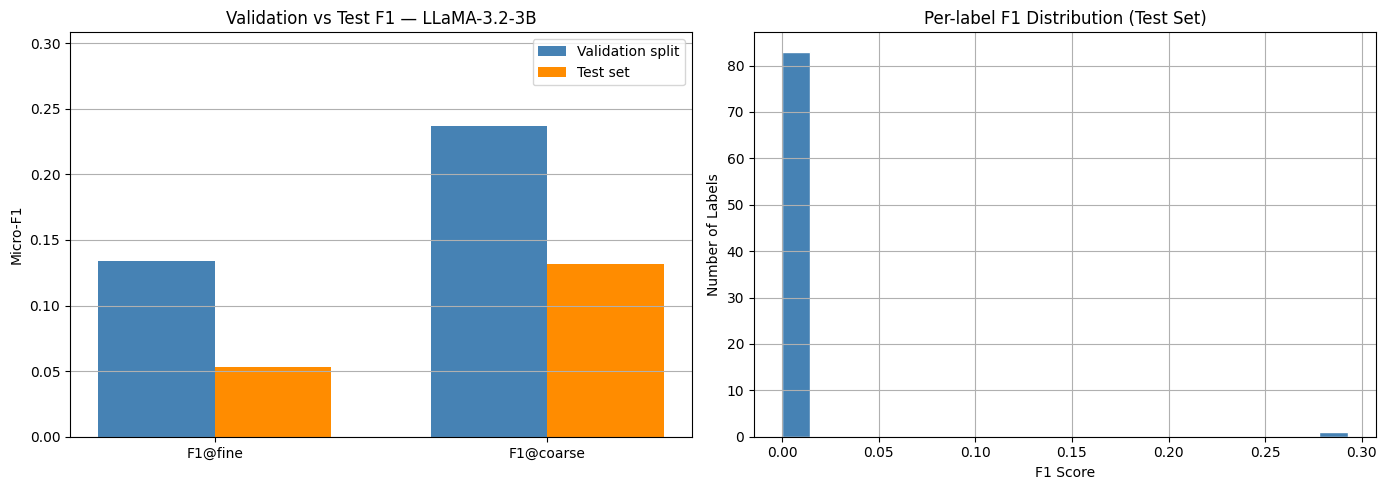

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: bar chart comparing validation and test F1 at both granularities
metrics   = ["F1@fine", "F1@coarse"]
val_vals  = [f1f_val, f1c_val]
test_vals = [f1f, f1c]
x = np.arange(len(metrics))
w = 0.35
axes[0].bar(x - w/2, val_vals,  w, label="Validation split", color="steelblue")
axes[0].bar(x + w/2, test_vals, w, label="Test set",         color="darkorange")
axes[0].set_title("Validation vs Test F1 — LLaMA-3.2-3B")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel("Micro-F1")
axes[0].set_ylim(0, max(max(val_vals), max(test_vals)) * 1.3)
axes[0].legend()
axes[0].grid(axis="y")

# Right: histogram of per-label F1 scores on the test set
axes[1].hist(per_label_f1, bins=20, color="steelblue", edgecolor="white")
axes[1].set_title("Per-label F1 Distribution (Test Set)")
axes[1].set_xlabel("F1 Score")
axes[1].set_ylabel("Number of Labels")
axes[1].grid(True)

plt.tight_layout()
plt.savefig("llm_subtask2_results.png", dpi=150)
plt.show()

### Experimental Analysis & Results Discussion

The LLaMA-3.2-3B model is fine-tuned via LoRA on the same 399 training samples
used for the DistilBERT and SVM baselines, reformulating multi-label classification
as a **text generation task**.

1. **Validation vs Test gap:** A notable difference between validation and test F1 is expected —
the model has access to world knowledge from pre-training, but 399 samples are insufficient
to reliably adapt it to the specific label space of this task.

2. **Per-Label F1 Distribution:** As with DistilBERT, rare sub-narrative labels are expected
to show F1≈0. The generative approach may handle some rare labels better than a classifier head
(by leveraging pre-trained semantic knowledge), but may also produce hallucinated labels
that are valid taxonomy entries but not applicable to the article.

3. **Comparison with SVM and DistilBERT:** Despite its size, the LLM approach faces the same
low-data regime constraints. SVM remains competitive because TF-IDF representations are
robust and sparse data-friendly. The LLM's advantage lies in zero-shot-like generalization
on label semantics — but this requires more data or few-shot prompting to manifest clearly.

## Save Predictions in Required Output Format

Format: `<article_id>\t<dominant_narratives>\t<sub_narratives>`

OLD


```
# Write predictions in the official SemEval format:
# article_id <TAB> dominant_narratives (semicolon-separated) <TAB> sub_narratives (semicolon-separated)
# If no sub-narrative is predicted, default to "Other" for both levels.
with open(OUTPUT_FILE, "w", encoding="utf-8") as fout:
    for i, row in df_test.iterrows():
        pred_subs = [
            sub_mlb.classes_[j]
            for j in range(len(sub_mlb.classes_))
            if pred_sub_test[i, j] == 1
        ]
        pred_doms = list(dict.fromkeys(
            sub2dom[s] for s in pred_subs if sub2dom.get(s)
        ))
        if not pred_subs:
            pred_subs = ["Other"]
            pred_doms = ["Other"]
        fout.write(f"{row['article_id']}\t{';'.join(pred_doms)}\t{';'.join(pred_subs)}\n")

print(f"Predictions saved to {OUTPUT_FILE}")
# Preview first 3 lines
with open(OUTPUT_FILE, "r", encoding="utf-8") as fin:
    for i, line in enumerate(fin):
        print(line.strip())
        if i >= 2: break
```



In [ ]:
# Write predictions in the official SemEval format:
# article_id <TAB> dominant_narratives (semicolon-separated) <TAB> sub_narratives (semicolon-separated)
# Logic mirrors fine_pred_to_coarse:
#   - if at least one real (non-Other) sub-narrative is predicted → use it and map to dominant
#   - if ALL predictions are 'Other' or nothing → write 'Other' for both levels
with open(OUTPUT_FILE, "w", encoding="utf-8") as fout:
    for i, (_, row) in enumerate(df_test.iterrows()):
        pred_subs = [
            sub_mlb.classes_[j]
            for j in range(len(sub_mlb.classes_))
            if pred_sub_test[i, j] == 1
        ]
        real_subs = [s for s in pred_subs if s != "Other"]

        if real_subs:
            pred_doms = list(dict.fromkeys(
                sub2dom[s] for s in real_subs if sub2dom.get(s)
            ))
            if not pred_doms:
                pred_doms = ["Other"]
            out_subs = real_subs
        else:
            out_subs  = ["Other"]
            pred_doms = ["Other"]

        fout.write(f"{row['article_id']}\t{';'.join(pred_doms)}\t{';'.join(out_subs)}\n")

---
> ***NLP Case Study - Subtask_2 (LLM/LoRA) | Manuel Carlucci | Mtr: 855237 | m.carlucci69@studenti.uniba.it***